# 01 — Data Exploration

---

### What this notebook does

Reads the seven files of the Nestlé DOM data pack and describes them: what is in each file, how
the keys line up, and which columns the model will actually need. It also rebuilds the **order
funnel** — how 1,109 open orders split into the ones that are fine and the ones that need help.

### What it does *not* do

It writes **nothing**. Nothing downstream depends on this notebook. Cleaning happens in `02`,
and the solvers (baseline, greedy and classical) read only what `02` produces. This notebook is here to be read.

### Where the rules come from

`DOM Equations.docx`, the 2022 business note inside the pack. The rules themselves are written
out and coded in notebook `02`.

## 1. Setup

### 1.1 Imports and the shared work folder

Every notebook in this repo points at the same `WORK` folder, so the cleaned files that `02`
writes are the ones `03`, `04` and `05` read.

In [1]:
import math
import numpy as np                       # arrays
import pandas as pd                      # tables
import matplotlib.pyplot as plt          # the funnel chart at the end

pd.set_option("display.width", 220)      # print wide tables
pd.set_option("display.max_columns", 80) # print many columns

Simply saying, this notebook is run in google colab, so the next cell saves any results in the online google drive.

In [2]:
import os, glob, zipfile

# Colab keeps nothing between runtimes, so the shared folder goes on Drive when we can.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = "/content/drive/MyDrive/DOM"
except Exception:
    WORK = os.path.abspath("dom_work")

CLEAN   = f"{WORK}/clean"      # notebook 02 writes here
RESULTS = f"{WORK}/results"    # notebooks 03, 04, 05 write here
os.makedirs(CLEAN, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)
print("work folder:", WORK)

Mounted at /content/drive
work folder: /content/drive/MyDrive/DOM


### 1.2 Find the data

Run this. Upload the zip if it asks. It unzips and locates the `DOM-data` folder. The zip that was given in this challenge details to download.

In [4]:
def find_dom_root():
    # search for a folder named DOM-data below the current folder, /content or WORK
    for pat in [f"{WORK}/**/DOM-data", "/content/**/DOM-data", "**/DOM-data"]:
        hits = [h for h in glob.glob(pat, recursive=True) if os.path.isdir(h)]
        if hits:
            return hits[0]
    return None

ROOT = os.environ.get("DOM_ROOT") or find_dom_root()   # is it already unzipped?
if ROOT is None:                                       # no -> we need the zip
    zips = glob.glob(f"{WORK}/*.zip") + glob.glob("/content/*.zip") + glob.glob("*.zip")
    if not zips:                                       # none there either
        from google.colab import files
        zips = list(files.upload().keys())             # ask the user to upload it
    with zipfile.ZipFile(zips[0]) as z:
        z.extractall(f"{WORK}/dom_extract")            # unzip it
    ROOT = find_dom_root()                             # look again

assert ROOT, "DOM-data folder not found"
IN = os.path.join(ROOT, "input data")                  # the 5 input files live here
print("found:", ROOT)

Saving Nestle - WISER WQ26 DOM-data [SHARED]-20260724T185420Z-1-001.zip to Nestle - WISER WQ26 DOM-data [SHARED]-20260724T185420Z-1-001.zip
found: /content/drive/MyDrive/DOM/dom_extract/Nestle - WISER WQ26 DOM-data [SHARED]/DOM-data


### 1.3 Load the files

Five input files. The two output files are the 2024 POC's own answer — we use them only to check
our work, never as model input.

In [5]:
orders = pd.read_csv(f"{IN}/input_order data.csv")           # one row per order + SKU
cap    = pd.read_csv(f"{IN}/input_capacity_planning.csv")    # daily stock per DC and SKU
dock   = pd.read_csv(f"{IN}/input_dock_capacity.csv")        # daily dock slots per DC
ship   = pd.read_csv(f"{IN}/input_shipping_cost_data.csv")   # cost per DC -> zip lane
thru   = pd.read_csv(f"{IN}/input_throughput_capacity.csv")  # daily pick workload per DC

poc_ord = pd.read_csv(f"{ROOT}/Output_order_level_data.csv")      # output file, check only
poc_sku = pd.read_csv(f"{ROOT}/output_order_sku_level_data.csv")  # output file, check only

for n, d in [("orders",orders), ("capacity",cap), ("dock",dock),
             ("shipping",ship), ("throughput",thru)]:
    print(f"{n:11s} {d.shape}")                              # rows, columns

orders      (25193, 39)
capacity    (377504, 23)
dock        (480, 13)
shipping    (12922, 7)
throughput  (530, 7)


## 2. What is in each file

### 2.1 The order book

`input_order data.csv` is one row per order line (order × SKU). `Group_Flag` is the order id.
The extract is already filtered: every row is full-truckload FTL and every delivery note is still
open, so two of the doc's rules are done for us. We test that rather than assume it.

In [6]:
print("rows:", len(orders), "| orders:", orders.Group_Flag.nunique(),
      "| SKUs:", orders.MaterialNumber.nunique(), "| DCs:", orders.Plant.nunique())

ftl = orders["IsFTL"].str.strip().str.upper().value_counts()             # count the FTL values
dnf = orders["DeliveryNoteFlag"].str.strip().str.upper().value_counts()  # count the open values
print("IsFTL:", ftl.to_dict(), "| DeliveryNoteFlag:", dnf.to_dict())
assert set(ftl.index) == {"Y"} and set(dnf.index) == {"N"}               # must be all Y and all N

print("plants:", sorted(orders.Plant.unique()))
print("priority:", orders.groupby("DeliveryPriority").Group_Flag.nunique().to_dict())

rows: 25193 | orders: 1109 | SKUs: 1110 | DCs: 8
IsFTL: {'Y': 25193} | DeliveryNoteFlag: {'N': 25193}
plants: [np.int64(5083), np.int64(5385), np.int64(5410), np.int64(5420), np.int64(5490), np.int64(5620), np.int64(5641), np.int64(5773)]
priority: {8: 12, 99: 1097}


### 2.2 The columns the model needs

Out of 39 columns in the order file, the model uses a dozen. This is the map from column to the
job it does.

In [9]:
use = pd.DataFrame([
    ("Group_Flag",                "order id"),
    ("Plant",                     "default DC the order sits at today"),
    ("MaterialNumber",            "SKU, relates to the stock ledger"),
    ("transportationplanningdate","planned ship day (PGI)"),
    ("RequestedDeliveryDate",     "customer due day, limits how far we can divert"),
    ("IsInvAvail",                "Y/N per line: covered by stock at the default DC"),
    ("DeliveryPriority",          "8 = protected order, 99 = normal"),
    ("OrderedQty_converted",      "quantity, in the unit named by ProductPlanningUnitOfMeasure"),
    ("ProductCasesPerPallet",     "cases per pallet, used for the pick split and PL->CS"),
    ("Order_SKU_Revenue",         "money on the line, the Sales term of the objective"),
    ("ZipCode",                   "ship-to zip, joins to the freight rate card explained in later section"),
    ("FillRateThreshold",         "fill % under which a penalty starts"),
    ("Penaltyforpotentialcuts",   "penalty rate applied to the missing value"),
], columns=["column", "what it is for"])
print(use.to_string(index=False))

                    column                                                         what it is for
                Group_Flag                                                               order id
                     Plant                                     default DC the order sits at today
            MaterialNumber                                       SKU, relates to the stock ledger
transportationplanningdate                                                 planned ship day (PGI)
     RequestedDeliveryDate                         customer due day, limits how far we can divert
                IsInvAvail                       Y/N per line: covered by stock at the default DC
          DeliveryPriority                                       8 = protected order, 99 = normal
      OrderedQty_converted            quantity, in the unit named by ProductPlanningUnitOfMeasure
     ProductCasesPerPallet                   cases per pallet, used for the pick split and PL->CS
         Order_SKU_R

### 2.3 The stock ledger

`input_capacity_planning.csv` is a daily ledger by DC × SKU. The model needs one number from it:
how many cases are free to use on a given day. That is `OpeningStock − Total_Reserved_Qty`.

In [10]:
cap["DATE"] = pd.to_datetime(cap["DATE"])
print("rows:", len(cap), "| DC-SKU pairs:", cap.groupby(["LocationID","MaterialID"]).ngroups)
print("days:", cap.DATE.min().date(), "->", cap.DATE.max().date(), f"({cap.DATE.nunique()} dates)")

DCS = sorted(orders["Plant"].unique())
print("locations in ledger:", sorted(cap.LocationID.unique()))
print("of which are our DCs:", [d for d in sorted(cap.LocationID.unique()) if d in DCS])

cap["AV"] = cap["OpeningStock"] - cap["Total_Reserved_Qty"]     # cases we may use
print("free stock >= 0 on", f"{(cap.AV >= 0).mean()*100:.1f}%", "of rows")

rows: 377504 | DC-SKU pairs: 11797
days: 2024-06-20 -> 2024-07-21 (32 dates)
locations in ledger: [np.int64(5081), np.int64(5082), np.int64(5083), np.int64(5159), np.int64(5376), np.int64(5385), np.int64(5410), np.int64(5420), np.int64(5423), np.int64(5490), np.int64(5620), np.int64(5641), np.int64(5773)]
of which are our DCs: [np.int64(5083), np.int64(5385), np.int64(5410), np.int64(5420), np.int64(5490), np.int64(5620), np.int64(5641), np.int64(5773)]
free stock >= 0 on 100.0% of rows


### 2.4 Docks, throughput and freight

Three small files. Two of them have gaps that shape the model, so it is worth seeing the gaps now
rather than being surprised in notebook `02`.

- **Docks** — `Dock_Remaining` is free slots per DC per day. Two DCs have no rows at all.
- **Throughput** — reports usage, never a limit. There is no capacity ceiling anywhere in the pack. It shows how many have been present per day but not the max capacity which is required in the constraints.
- **Freight** — a full rate card, so every DC can quote every ship-to zip.

In [11]:
dock["Date"] = pd.to_datetime(dock["Date"], format="%m/%d/%y")
print("dock rows:", len(dock), "| DCs with dock rows:", sorted(dock.Plant.unique()))
print("DCs with NO dock rows:", [d for d in DCS if d not in set(dock.Plant)])
print("fully booked DC-days (Dock_Remaining == 0):", int((dock.Dock_Remaining == 0).sum()))

print("\nthroughput rows:", len(thru), "| columns:", list(thru.columns))
print("-> reports util_case_picks / util_pallets only: usage, no stated maximum")

print("\nfreight rows:", len(ship))
lanes = set(zip(ship.Plant, ship.TargetZip))
need  = set((d, z) for d in DCS for z in orders.ZipCode.unique())
print("DC -> ship-to-zip lanes missing from the rate card:", len(need - lanes))

dock rows: 480 | DCs with dock rows: [np.int64(5159), np.int64(5385), np.int64(5410), np.int64(5420), np.int64(5423), np.int64(5490), np.int64(5620), np.int64(5641)]
DCs with NO dock rows: [np.int64(5083), np.int64(5773)]
fully booked DC-days (Dock_Remaining == 0): 43

throughput rows: 530 | columns: ['Plant', 'transportationplanningdate', 'util_case_picks', 'util_pallets', 'order_count', 'Day', 'Report_Run_Date']
-> reports util_case_picks / util_pallets only: usage, no stated maximum

freight rows: 12922
DC -> ship-to-zip lanes missing from the rate card: 0


### 2.5 Lead time is not given, but it is recoverable

Nothing in the pack states a transit time. The POC output does, though, and it is simply
`ceil(distance / 500)`. We check that against both of its lead-time columns before notebook `02`
relies on it.

Lead time is the total amount of time that elapses from the moment a process or order is initiated until it is fully completed and delivered.

It is not directly present in the input files but found in the output files, but we can calculate from a column in the output file and compare it with another column in the output file to check that we are correct with the equation representing the lead time.

In [12]:
v = poc_ord[["DefaultDCDistance","DefaultDCLeadTime"]].dropna().drop_duplicates()
acc = (np.maximum(1, np.ceil(v.DefaultDCDistance/500)) == v.DefaultDCLeadTime).mean()
print("lead time == ceil(distance / 500):", round(acc, 6))
assert acc == 1.0                        # stop here if the rule is wrong

lead time == ceil(distance / 500): 1.0


## 3. Units: pallets have to become cases

The doc works in cases. Most order lines are already cases (`CS`), but some are pallets (`PL`).
Converting those with `ProductCasesPerPallet` reproduces the POC's own `OrderedQty_Cases`
exactly, which is the strongest check available that we read the file the way the dataset provider did.

By other words, in the input files some are (`PL`) but the output file POC shows them as (`CS`) so we convert.

In [13]:
print(orders.ProductPlanningUnitOfMeasure.value_counts().to_dict())

cases = np.where(orders["ProductPlanningUnitOfMeasure"].eq("PL"),                # pallets?
                 orders["OrderedQty_converted"] * orders["ProductCasesPerPallet"],  # -> cases
                 orders["OrderedQty_converted"]).astype(float)                   # already cases

chk = orders.assign(cases=cases).merge(                                          # join to the POC
    poc_sku[["SalesDocument/GroupingIndicator","MaterialNumber","OrderedQty_Cases"]],
    left_on=["Group_Flag","MaterialNumber"],
    right_on=["SalesDocument/GroupingIndicator","MaterialNumber"], how="left")
print("conversion matches POC:", round((chk["cases"] == chk["OrderedQty_Cases"]).mean(), 6))

{'CS': 24820, 'PL': 373}
conversion matches POC: 1.0


## 4. The funnel

The doc turns 1,109 open orders into a shorter list of **focus orders** — the ones a planner has
to make a decision about. Two things put an order on that list.

1. **Short on stock.** An order is short if *any* of its lines has `IsInvAvail = N`. Each order is made of multiple SKU's, one or more SKU might have `IsInvAvail = N`.
2. **No room to ship.** The doc adds orders when a DC runs out of throughput for three days
   running. The pack has no throughput limit, only usage, so a fully booked dock day
   (`Dock_Remaining = 0`) stands in for it.

Everything else is clean and stays where it is.

In [14]:
head_dc  = orders.groupby("Group_Flag")["Plant"].first()                    # default DC
head_pgi = orders.groupby("Group_Flag")["transportationplanningdate"].first()
head_pgi = pd.to_datetime(head_pgi, format="%m/%d/%y")                      # planned ship day

roll   = orders.groupby("Group_Flag")["IsInvAvail"].apply(lambda s: (s.str.upper() == "Y").all())
SUFF   = set(roll[roll].index)      # every line is fine
INSUFF = set(roll[~roll].index)     # at least one line is short

zero_days = set(map(tuple,                                     # (plant, day) with no free dock
                    dock.loc[dock["Dock_Remaining"] == 0, ["Plant","Date"]]
                        .drop_duplicates().values))
FLAGGED = {g for g in head_dc.index if (head_dc[g], head_pgi[g]) in zero_days}
ADDED   = FLAGGED & SUFF            # keep only the ones that were otherwise fine
FOCUS   = sorted(INSUFF | ADDED)
CLEANO  = sorted(set(head_dc.index) - set(FOCUS))

print(f"open orders      : {len(head_dc)}")
print(f"  short on stock : {len(INSUFF)}")
print(f"  + full dock day: {len(ADDED)}")
print(f"  = FOCUS ORDERS : {len(FOCUS)}")
print(f"  clean, stay put: {len(CLEANO)}")

open orders      : 1109
  short on stock : 447
  + full dock day: 25
  = FOCUS ORDERS : 472
  clean, stay put: 637


### 4.1 The funnel as a picture

Same numbers, drawn. This is the shape the model input takes.

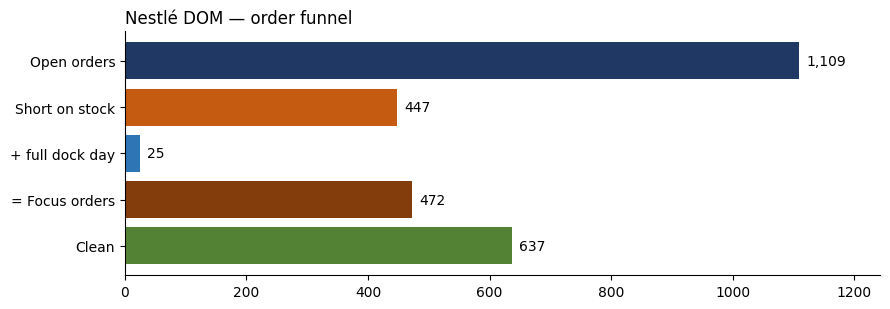

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.2))
bars = [("Open orders", len(head_dc), "#1f3864"),
        ("Short on stock", len(INSUFF), "#c55a11"),
        ("+ full dock day", len(ADDED), "#2e75b6"),
        ("= Focus orders", len(FOCUS), "#833c0c"),
        ("Clean", len(CLEANO), "#548235")]
ax.barh([b[0] for b in bars][::-1], [b[1] for b in bars][::-1],
        color=[b[2] for b in bars][::-1])
for i, b in enumerate(bars[::-1]):
    ax.text(b[1] + 12, i, f"{b[1]:,}", va="center", fontsize=10)
ax.set_xlim(0, len(head_dc) * 1.12)
ax.set_title("Nestlé DOM — order funnel", loc="left", fontsize=12)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 4.2 Cross-check against the POC's own output

The POC file counts orders by comparing cases filled against cases ordered, not by the
`IsInvAvail` flag. The two views should agree in size and direction without being identical —
the flag is a snapshot taken before the model ran, the case counts are what it managed afterwards.

The case counts (comparing cases filled against cases ordered) record what actually happened after the proof-of-concept (POC) model finished running. The model might have reallocated stock, pulled from alternative locations, or partially filled orders, altering the final outcome.

In [16]:
short_poc = (poc_ord.Default_Qty_Cases < poc_ord.OrderedQty_Cases).sum()
print(f"ours (IsInvAvail = N on any line) : {len(INSUFF)} short / {len(SUFF)} fine")
print(f"POC (filled < ordered)            : {short_poc} short / {len(poc_ord)-short_poc} fine")
print(f"\nPOC recommended a divert for      : {int((poc_ord.IsDivert != 'Default').sum())} orders")

ours (IsInvAvail = N on any line) : 447 short / 662 fine
POC (filled < ordered)            : 486 short / 623 fine

POC recommended a divert for      : 3 orders


## 5. What we found

* The order file is pre-filtered — FTL and open — so those two doc rules cost us nothing. By other words they are already implemented/filtered in the given dataset.
* Pallet lines convert to cases exactly as the POC did, so the quantities are trustworthy.
* **Three things the pack does not contain**, each of which forces an assumption in `02`:
  a throughput ceiling, a holiday calendar, and a demand forecast.
* Two DCs have no dock rows, so a dock check cannot be applied there.
* Lead time is recoverable from distance and matches the POC on every row.
* The funnel gives **472 focus orders**; the other 637 are fulfilled from their default DC.

Next: `02_data_cleaning` turns all of this into model input, and writes down the rules/constraints.